In [1]:
print("Morning!")

Morning!


In [2]:
# Basic imports Andrej do every time.
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

$$f(x)=3x^2-4x+5$$

In [3]:
# def f(x):
#     """A demo function for micrograd.
#     which takes a number x and returns another number calculated based on x."""
#     return 3 * x ** 2 - 4 * x + 5
# print(f(3.0))

In [4]:
def draw_derivative(f, x, h) -> float:
    """Draw fx and the tangent line of fx, to demonstrate derivative."""
    slope  = (f(x + h) - f(x)) / h

    def line(t):
        return slope * (t - x) + f(x)

    x_axis = np.arange(x - 10, x + 10, 0.25)
    y_axis = f(x_axis)
    lineax = line(x_axis)
    plt.plot(x_axis, y_axis)
    plt.plot(x_axis, lineax)

    return slope

# Try a bit maybe.
# draw_derivative(f, 0.0, 0.001)

In [5]:
# xs = np.arange(-5, 5, 0.25)
# ys = f(xs)
# print(xs)
# print(ys)
# plt.plot(xs, ys)

In [6]:
class Value:
    """The value object that refers to micrograd."""
    def __init__(self, data, _children = (), _op = '', label=''):
        self.data = data
        self.grad = 0 # When initializing, we assume all variables have no impact on output.
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self) -> str:
        """wrapper prints a value with a nicer looking."""
        # if self._op == '':
        #     return f"Value(data={self.data}, children={self._prev})"
        # else:
        #     return f"Value(data={self.data}, children={self._prev}, _op={self._op})"
        return f"Value(data = {self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - out.data ** 2) * out.grad
        # out._backward = _backward() ->TypeError: 'NoneType' object is not callable
        out._backward = _backward
        return out

    def backward(self):
    # Topological Sort
        topo = []
        visited = set()

        def build_topo(v: Value) -> None:
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

def value_demo() -> None:
    a = Value(-2.0, label='a')
    b = Value(3.0, label='b')
    plus = a + b
    plus.label = 'plus'
    multiply = a * b
    multiply.label = 'multiply'
    print(f"a:{a}")
    print(f"b:{b}")
    print(f"a + b => {plus}")
    print(f"a * b => {multiply}")

In [7]:
# Cut from Andrej Karpathy, collected by LLM.

from graphviz import Digraph
from typing import Set, Tuple, Any

def trace(root: Any) -> Tuple[Set[Any], Set[Tuple[Any, Any]]]:
    """
    从根节点出发，递归遍历整个计算图，收集所有节点和边。
    Args:
        root: 计算图的根节点（输出 Value 对象）。
    Returns:
        nodes: 图中所有节点的集合。
        edges: 图中所有有向边的集合，每条边为 (子节点, 父节点)。
    """
    nodes: Set[Any] = set()
    edges: Set[Tuple[Any, Any]] = set()

    def build(v: Any) -> None:
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root: Any) -> Digraph:
    """
    将计算图渲染为 Graphviz 的有向图对象（从左到右布局）。
    每个 Value 节点显示：标签名 | data 值 | grad 梯度。
    若节点由运算产生，则额外绘制一个运算节点（+、* 等）连接到该 Value 节点。
    Args:
        root: 计算图的根节点（最终输出 Value 对象）。
    Returns:
        dot: 一个 graphviz.Digraph 对象，可直接在 Jupyter 中渲染，
             或调用 .render() 保存为 svg / png 文件。
    """
    dot = Digraph(
        format='svg',
        graph_attr={'rankdir': 'LR'},  # LR = Left to Right，从左到右
        node_attr={'fontname': 'Helvetica'},
    )

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # 为每个 Value 对象画一个 record 形状的节点
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape='record',
        )
        # 如果该节点是运算的结果，再画一个运算节点并连到 Value 节点
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # 子节点 → 父节点的运算节点
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

# a simple tree graph demo
# a = Value(-2.0, label='a')
# b = Value(3.0, label='b')
# c = a * b
# c.label = 'c'
# d = Value(4.0, label='d')
# e = d + c
# e.label = 'e'
# f_value = Value(-5.0, label='f')
# root = e * f_value
# root.label = 'root'
#
# draw_dot(root)

neural networks belike:
$$\sum w_ix_i + b\quad\underrightarrow{\text{activation function}}$$

In [8]:
# below have no activation function.
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# neural bias b
b  = Value(6.881373587019, label='b')

# multiply
x1w1 = x1 * w1
x1w1.label = 'x1 * w1'
x2w2 = x2 * w2
x2w2.label = 'x2 * w2'

# \sum w_ix_i + b
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b
n.label = 'n'
o = n.tanh()
o.label = 'o'

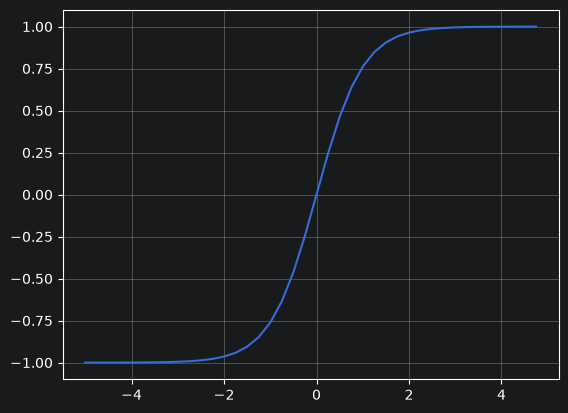

In [9]:
# now use tanh as activation function

ax_x = np.arange(-5, 5, 0.25)
ax_y = np.tanh(ax_x)

plt.plot(ax_x, ax_y); plt.grid();

In [10]:
# def simple_back_prop(root: Value) -> None:
#     """A simple back propagation algorithm based on recursion.
#     Args: root value
#     Returns: returns None but mutates root value object"""
#     ptr = root
#     ptr.grad = 1.0
#
#     for child in ptr._prev:
#         if ptr._op == '+':
#             child.grad += ptr.grad
#         elif ptr._op == '*':
#             child1, child2 = tuple(ptr._prev)
#             child1.grad += child2.data * ptr.grad
#             child2.grad += child1.data * ptr.grad
#         elif ptr._op == 'tanh':
#             child.grad += ptr.grad / (math.cosh(child.data) ** 2)
#         simple_back_prop(child)

# def simple_back_prop(root: Value) -> None:
#     """A simple back propagation algorithm based on recursion.
#     Args: root value
#     Returns: returns None but mutates root value object"""
#     visited = set()
#
#     def _backward(v):
#         if v in visited:
#             return
#         visited.add(v)
#
#         if v._op == '+':
#             for child in v._prev:
#                 child.grad += v.grad
#         elif v._op == '*':
#             a, b = tuple(v._prev)
#             a.grad += b.data * v.grad
#             b.grad += a.data * v.grad
#         elif v._op == 'tanh':
#             for child in v._prev:
#                 child.grad += (1 - v.data ** 2) * v.grad
#
#         for child in v._prev:
#             _backward(child)
#
#     root.grad = 1.0
#     _backward(root)
#
# simple_back_prop(o)
# draw_dot(o)

## The difference between
```Python
def simple_back_prop_wrong(root: Value) -> None:
    """A simple back propagation algorithm based on recursion.
    Args: root value
    Returns: returns None but mutates root value object"""
    ptr = root
    ptr.grad = 1.0
    for child in ptr._prev:
        if ptr._op == '+':
            child.grad += ptr.grad
        elif ptr._op == '*':
            child1, child2 = tuple(ptr._prev)
            child1.grad += child2.data * ptr.grad
            child2.grad += child1.data * ptr.grad
        elif ptr._op == 'tanh':
            child.grad += ptr.grad / (math.cosh(child.data) ** 2)
        simple_back_prop(child)

def simple_back_prop_right(root: Value) -> None:
    visited = set()

    def _backward(v):
        if v in visited:
            return
        visited.add(v)

        if v._op == '+':
            for child in v._prev:
                child.grad += v.grad
        elif v._op == '*':
            a, b = tuple(v._prev)
            a.grad += b.data * v.grad
            b.grad += a.data * v.grad
        elif v._op == 'tanh':
            for child in v._prev:
                child.grad += (1 - v.data ** 2) * v.grad

        for child in v._prev:
            _backward(child)
```

---
the wrong answer exists repeated calculation, visited set added, get the correct answer by memorization.

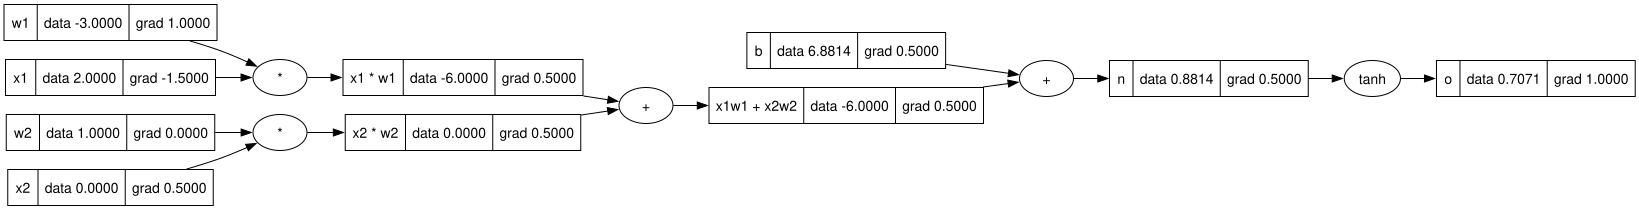

In [14]:
draw_dot(o)

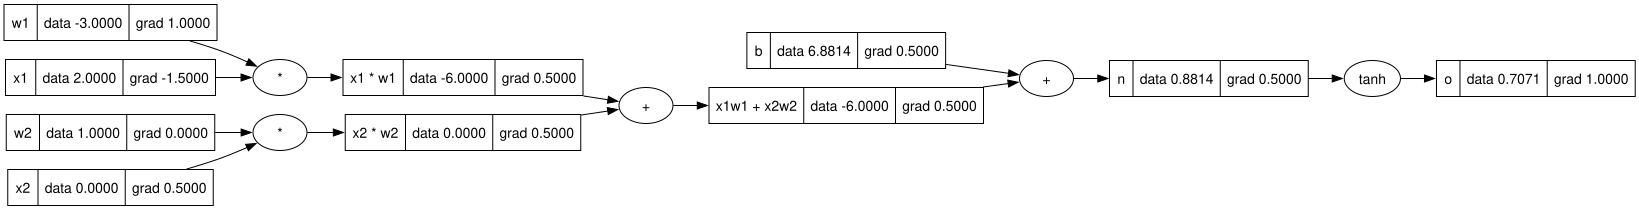

In [12]:
o.backward()
draw_dot(o)

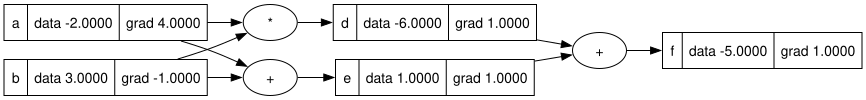

In [13]:
a = Value(-2.0, label='a')
b = Value(3.0,  label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d + e; f.label = 'f'
f.backward()
draw_dot(f)